# YAFS Link Trace Analysis

This notebook analyzes the `sim_trace_link.csv` file, which contains detailed logs of message transmissions over network links in the YAFS simulation.

**Key Metrics Analyzed:**
- **Latency:** The time taken for a message to travel from source to destination.
- **Traffic Volume:** The number of messages and total data size transferred between nodes.
- **Buffer Usage:** The utilization of link buffers during the simulation.
- **Network Topology:** Communication patterns between different nodes (Fog, Cloud, Sensors).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
We will load the `sim_trace_link.csv` file and examine its structure, data types, and basic statistics.

In [8]:
# Load the dataset
file_path = 'resultados/sim_trace_link.csv'
df_link = pd.read_csv(file_path)

# Display the first few rows
display(df_link.head())

# Check data types and missing values
print(df_link.info())

# Basic descriptive statistics
display(df_link.describe())

,id,type,src,dst,srcLabel,dstLabel,app,latency,message,ctime,size,buffer
0,1,LINK,14,13,Application-1-Sensor,Application-1-Router,Application-1,1.0005,Sensor calling Service,100.0,1000,0
1,2,LINK,17,16,Application-2-Sensor,Application-2-Router,Application-2,1.0005,Sensor calling Service,100.0,1000,1
2,3,LINK,20,19,Application-3-Sensor,Application-3-Router,Application-3,1.0005,Sensor calling Service,100.0,1000,2
3,4,LINK,23,22,Application-4-Sensor,Application-4-Router,Application-4,1.0005,Sensor calling Service,100.0,1000,3
4,5,LINK,26,25,Application-5-Sensor,Application-5-Router,Application-5,1.0005,Sensor calling Service,100.0,1000,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12364 entries, 0 to 12363
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        12364 non-null  int64  
 1   type      12364 non-null  object 
 2   src       12364 non-null  int64  
 3   dst       12364 non-null  int64  
 4   srcLabel  12364 non-null  object 
 5   dstLabel  12364 non-null  object 
 6   app       12364 non-null  object 
 7   latency   12364 non-null  float64
 8   message   12364 non-null  object 
 9   ctime     12364 non-null  float64
 10  size      12364 non-null  int64  
 11  buffer    12364 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 1.1+ MB
None


,id,src,dst,latency,ctime,size,buffer
count,12364.000000,12364.000000,12364.000000,12364.000000,12364.000000,12364.000000,12364.000000
mean,808.001941,16.525558,16.631834,8.239539,5141.683607,750.404400,13.501294
std,448.286531,17.737722,17.874621,6.950634,2805.656670,250.009784,5.427535
min,1.000000,0.000000,0.000000,1.000250,100.000000,500.000000,0.000000
25%,423.000000,3.000000,3.000000,1.000500,2722.000758,500.000000,10.000000
50%,809.000000,9.000000,9.000000,5.000125,5158.000707,1000.000000,14.000000
75%,1196.000000,28.000000,28.000000,8.000067,7578.000722,1000.000000,18.000000
max,1584.000000,59.000000,60.000000,20.000010,9998.000732,1000.000000,23.000000


## 2. Latency Analysis
Latency is a critical metric in network simulations. We will analyze the distribution of latency and compare it across different applications.

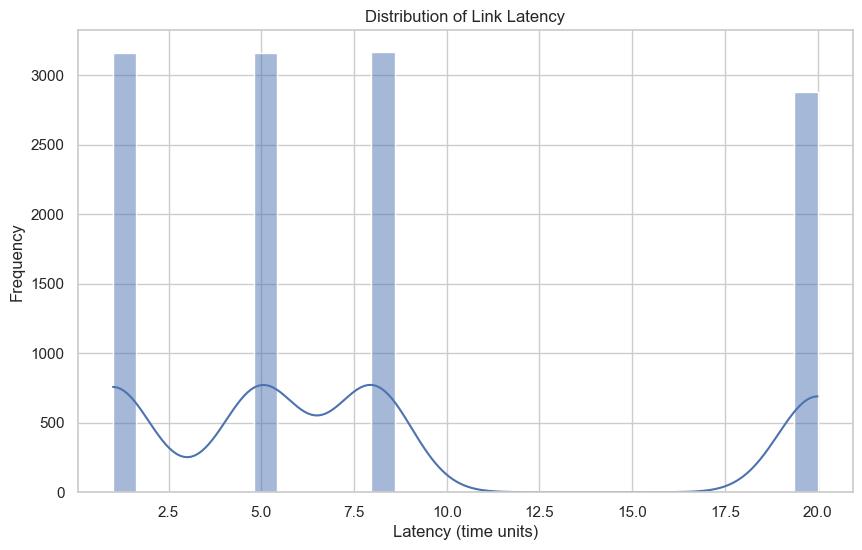

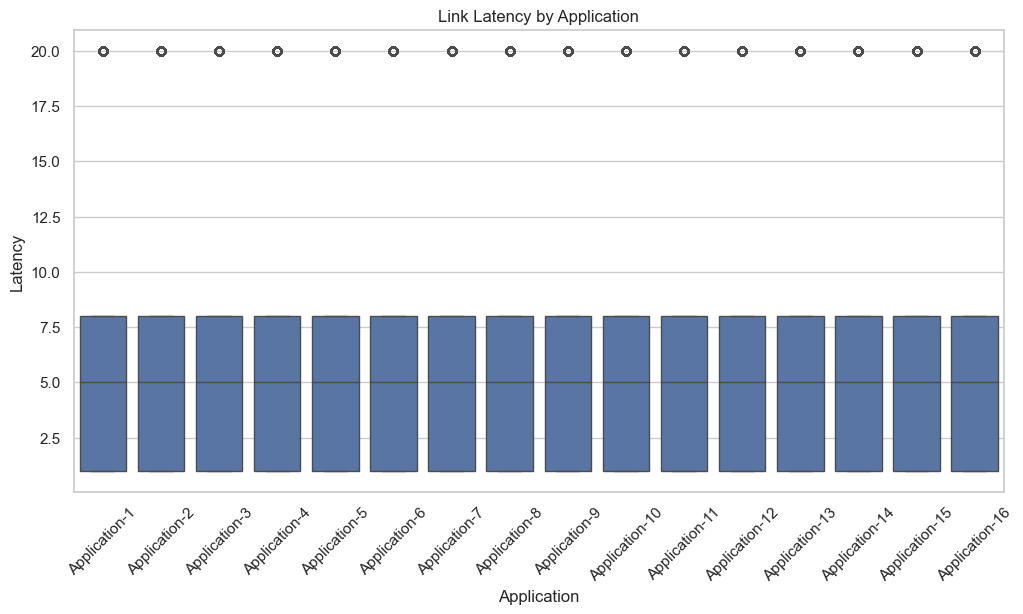

In [9]:
# Latency Distribution Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_link['latency'], kde=True, bins=30)
plt.title('Distribution of Link Latency')
plt.xlabel('Latency (time units)')
plt.ylabel('Frequency')
plt.show()

# Latency by Application Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='app', y='latency', data=df_link)
plt.title('Link Latency by Application')
plt.xlabel('Application')
plt.ylabel('Latency')
plt.xticks(rotation=45)
plt.show()

### Latency Trends Over Time
Analyzing how latency changes over time can reveal network congestion or the impact of dynamic placement strategies. We bin the simulation time into windows and calculate the average latency for each window.

In [ ]:
# Define time window size for averaging (e.g., 500 time units)
# You can adjust this value based on your simulation duration
window_size = 500 

# Create a new column for time windows
df_link['time_window'] = (df_link['ctime'] // window_size) * window_size

# Calculate mean latency per time window
latency_trend = df_link.groupby('time_window')['latency'].mean().reset_index()

# Plot Global Average Latency
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_window', y='latency', data=latency_trend, marker='o')
plt.title(f'Average Latency Over Time (Window Size: {window_size})')
plt.xlabel('Simulation Time')
plt.ylabel('Average Latency')
plt.grid(True)
plt.show()

# Plot Average Latency per Application
plt.figure(figsize=(12, 6))
latency_trend_app = df_link.groupby(['time_window', 'app'])['latency'].mean().reset_index()
sns.lineplot(x='time_window', y='latency', hue='app', data=latency_trend_app, marker='o')
plt.title(f'Average Latency Over Time per Application')
plt.xlabel('Simulation Time')
plt.ylabel('Average Latency')
plt.legend(title='Application', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## 3. Traffic Analysis
We will analyze the volume of traffic generated by each application and visualize the communication patterns between nodes using a heatmap.

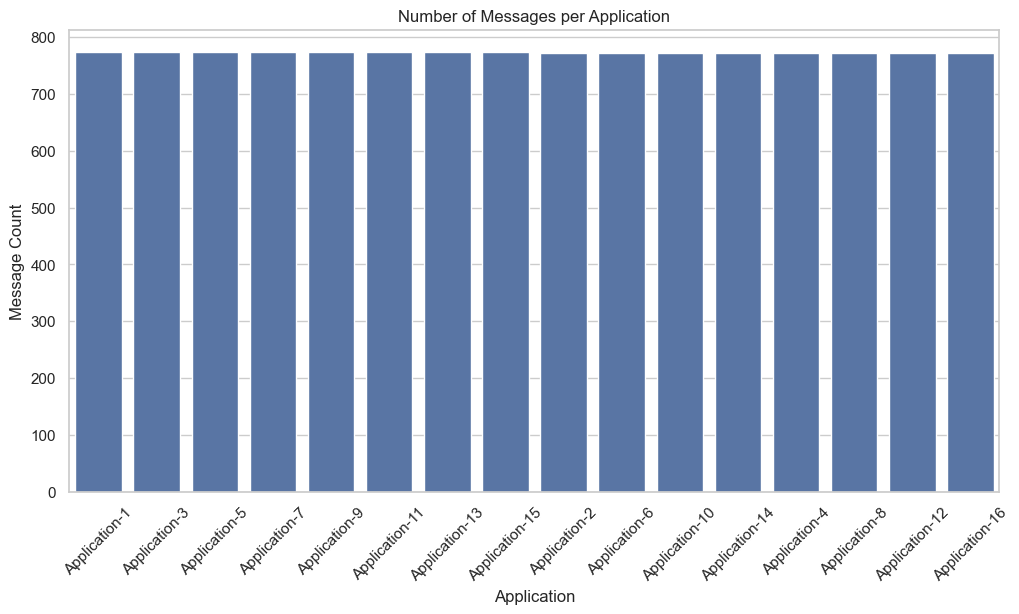

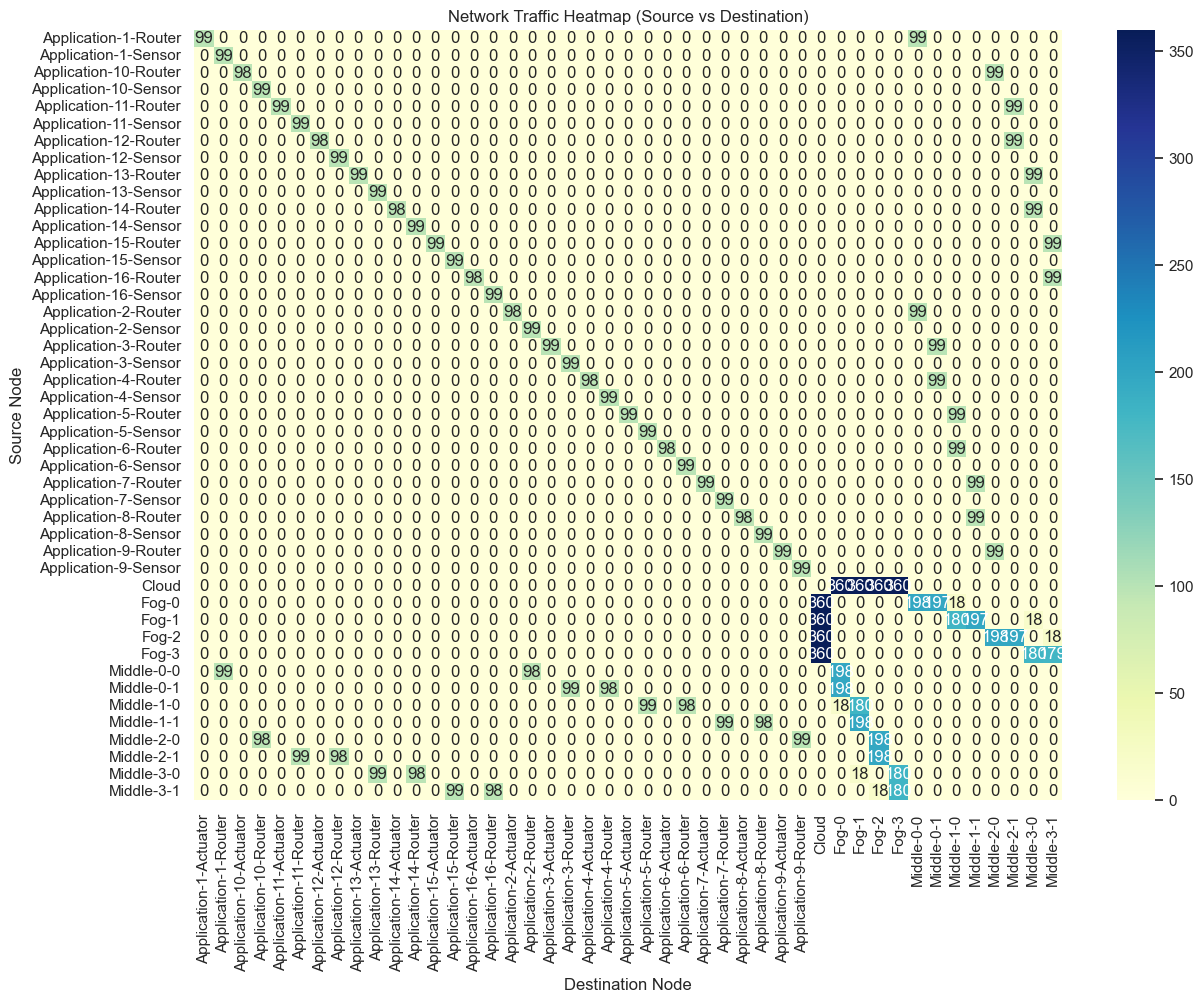

In [10]:
# Message Count per Application
plt.figure(figsize=(12, 6))
sns.countplot(x='app', data=df_link, order=df_link['app'].value_counts().index)
plt.title('Number of Messages per Application')
plt.xlabel('Application')
plt.ylabel('Message Count')
plt.xticks(rotation=45)
plt.show()

# Communication Heatmap (Source vs Destination)
# Create a pivot table counting occurrences
heatmap_data = pd.crosstab(df_link['srcLabel'], df_link['dstLabel'])

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Network Traffic Heatmap (Source vs Destination)')
plt.xlabel('Destination Node')
plt.ylabel('Source Node')
plt.show()

## 4. Buffer Usage Analysis
Understanding buffer usage is crucial for identifying potential congestion points. We will look at the distribution of buffer sizes and how buffer usage changes over time.

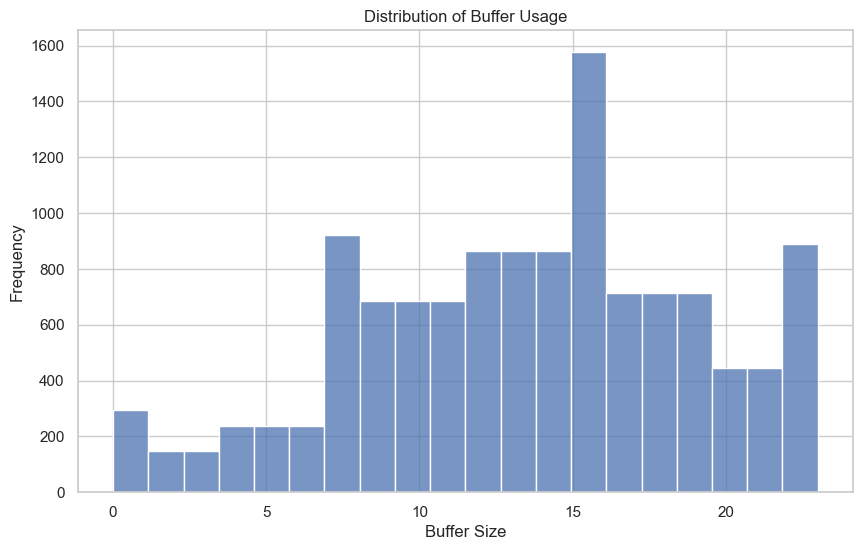

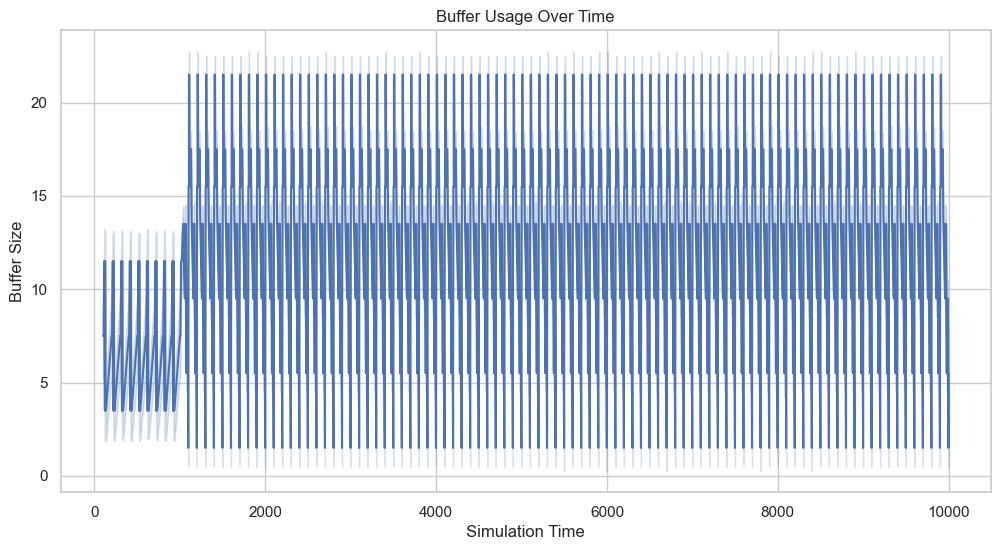

In [11]:
# Buffer Size Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_link['buffer'], bins=20, kde=False)
plt.title('Distribution of Buffer Usage')
plt.xlabel('Buffer Size')
plt.ylabel('Frequency')
plt.show()

# Buffer Usage Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='ctime', y='buffer', data=df_link)
plt.title('Buffer Usage Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Buffer Size')
plt.show()

## 5. Throughput Analysis
We will visualize the cumulative data transferred over the network to understand the throughput of the system.

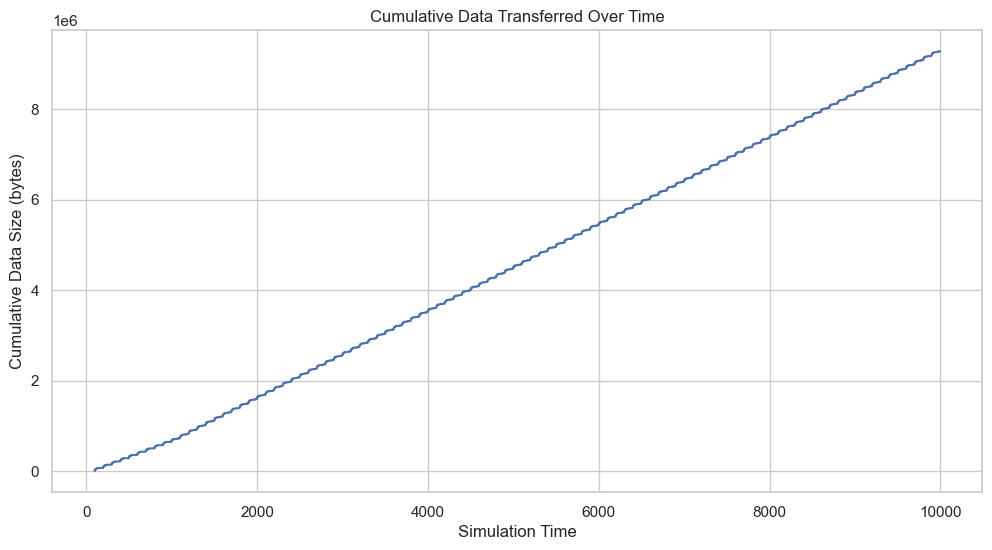

In [12]:
# Sort by time
df_link_sorted = df_link.sort_values('ctime')

# Calculate cumulative size
df_link_sorted['cumulative_size'] = df_link_sorted['size'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(df_link_sorted['ctime'], df_link_sorted['cumulative_size'])
plt.title('Cumulative Data Transferred Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Cumulative Data Size (bytes)')
plt.show()

## 6. Conclusion
This notebook provides a detailed analysis of the network link traces.
- **Latency**: Check if any application experiences abnormal delays.
- **Traffic**: Identify the most communicative nodes using the heatmap.
- **Buffer**: Ensure buffers are not consistently full, which would indicate congestion.
- **Throughput**: Observe the rate of data transfer over the simulation period.